# The Fourth Circle: Neural Networks, Part Three 
## Recurrent Neural Networks IV: Encoder-Decoder Network

<br/>
Jiří Fejlek

2026-04-03
<br/>

## Table of Contents

- [Tatoeba Project Dataset](#tatoeba)
- [Encoder-Decoder Model](#encoder-decoder)
    - [Training Encoder-Decoder Model](#training-encoder-decoder)
    - [Computing Predictions](#predictions)
    - [BLEU](#bleu)
    - [Advanced Encoder-Decoder Model](#advanced)
- [References](#references)

An encoder-decoder architecture [[1](#1), [2](#2)] deals with general sequence problems in which the input and output sequences have varying lengths. A typical example of such a task is *machine translation* in which the goal is to algorithmically translate a piece of text from one language to another. 

An encoder-decoder model consists of two main elements, as the name would suggest. An *encoder*  processes input sequences and generates outputs of fixed length that serve as a representation of the original sequence. A *decoder* then takes the output of the encoder as an input and produces the final output sequence.

## Tatoeba Project Dataset Dataset <a class="anchor" id="tatoeba"></a>

As a dataset for this project, we will use bilingual sentence pairs from https://www.manythings.org/anki/ based on the Tatoeba project https://tatoeba.org/en. 

In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

import torchvision
import torch

from torch import nn
from torch.utils.data import DataLoader
import torch.nn.functional as F

import re
import collections
import os

np.set_printoptions(legacy='1.25')

In [2]:
cuda_device = torch.device('cuda')
torch.cuda.get_device_name(cuda_device)

'NVIDIA GeForce RTX 4070 Ti'

Namely, we will use a dataset consisting of English and Czech sentences.

In [3]:
with open('D:/nine circles 2/ces.txt', encoding='utf-8') as f:
    tatoeba = f.read()
print(tatoeba[:644])

Hi.	Ahoj!	CC-BY 2.0 (France) Attribution: tatoeba.org #538123 (CM) & #373338 (lipao)
Run!	Běž!	CC-BY 2.0 (France) Attribution: tatoeba.org #906328 (papabear) & #8732877 (aldar)
Run!	Utíkej!	CC-BY 2.0 (France) Attribution: tatoeba.org #906328 (papabear) & #8732879 (aldar)
Who?	Kdo?	CC-BY 2.0 (France) Attribution: tatoeba.org #2083030 (CK) & #7758419 (MajaHled)
Wow!	Páni!	CC-BY 2.0 (France) Attribution: tatoeba.org #52027 (Zifre) & #7488269 (Ergulis)
Duck!	Skrč se!	CC-BY 2.0 (France) Attribution: tatoeba.org #280158 (CM) & #10621029 (hassman)
Fire!	Hoří!	CC-BY 2.0 (France) Attribution: tatoeba.org #1829639 (Spamster) & #7967410 (Ergulis)



In [4]:
print(tatoeba[-727:-1])

January, February, March, April, May, June, July, August, September, October, November and December are the twelve months of the year.	Leden, únor, březen, duben, květen, červen, červenec, srpen, září, říjen, listopad a prosinec je dvanáct ročních měsíců.	CC-BY 2.0 (France) Attribution: tatoeba.org #621957 (Eldad) & #3467838 (nueby)
Making people dependent on government handouts is not going to benefit the economy or incentivize individuals to become productive members of society.	Učinit lidi závislými na státních dávkách hospodářství neprospěje a nebude to povzbuzovat jednotlivce k tomu, aby se stali produktivními členy společnosti.	CC-BY 2.0 (France) Attribution: tatoeba.org #6025238 (mailohilohi) & #12447609 (jms)


First, we insert spaces between words and punctuation marks (punctuation marks will serve as separate tokens) using the code taken from [[3](#3)]. We also need to remove the parts that denote the source of the sentences. Lastly, we should keep in mind that the sentences appear to be sorted by length. Hence, we should randomly shuffle them before splitting into the training and test sets.

In [5]:
def _preprocess(text):
    no_space = lambda char, prev_char: char in ',.!?' and prev_char != ' '
    out = [' ' + char if i > 0 and no_space(char, text[i - 1]) else char
           for i, char in enumerate(text.lower())]
    return ''.join(out)

In [6]:
tatoeba = []
i = 0
with open('D:/nine circles 2/ces.txt', encoding='utf-8') as file:
    lines = [line.rstrip() for line in file]

for line in lines:
    line = _preprocess(line)
    idx = line.find("cc-by")
    tatoeba.append(line[:idx-1])

tatoeba[:15]

['hi .\tahoj !',
 'run !\tběž !',
 'run !\tutíkej !',
 'who ?\tkdo ?',
 'wow !\tpáni !',
 'duck !\tskrč se !',
 'fire !\thoří !',
 'fire !\toheň !',
 'stop !\tstát !',
 'wait !\tpočkej !',
 'hello !\tahoj !',
 'hurry !\tpospěš si !',
 'hurry !\tdělej !',
 'i see .\taha .',
 'i see .\tach tak .']

The number of sentence pairs is as follows.

In [7]:
len(tatoeba)

41869

Next, we need to split the pairs. We will also add two special tokens: the *\<eos\>* token denotes the end of the sequence in both languages, and the *\<bos\>* token denotes the beginning of the sequence. We will use the *\<bos\>* token only in the sequences for one of the languages, specifically the language we will be translating *to*. As we will see later, the *\<bos\>* token will serve as the first input token for the decoder. 

We will consider the task of translating from English to Czech and, consequently, add *\<bos\>* to the Czech lines.

In [8]:
tatoeba[0].split('\t')

['hi .', 'ahoj !']

In [9]:
eng_text = []
ces_text = []

for lines in tatoeba:
    words = lines.split('\t')
    if len(words) == 2:
        eng_text.append([t for t in f'{words[0]} <eos>'.split(' ') if t])
        ces_text.append([t for t in f'<bos> {words[1]} <eos>'.split(' ') if t])

Overall, we get two sets: *eng_text* and *ces_text*, lines in English and Czech, prepared for tokenization.

In [10]:
eng_text[-10]

['when',
 'tom',
 'was',
 'working',
 'on',
 'the',
 'dairy',
 'farm',
 ',',
 'he',
 'had',
 'to',
 'get',
 'up',
 'at',
 'five',
 "o'clock",
 'every',
 'morning',
 'to',
 'go',
 'and',
 'milk',
 'the',
 'cows',
 '.',
 '<eos>']

In [11]:
ces_text[-10]

['<bos>',
 'když',
 'tom',
 'pracoval',
 'na',
 'mléčném',
 'statku',
 ',',
 'musel',
 'vstát',
 'každé',
 'ráno',
 'v',
 'pět',
 'hodin',
 'a',
 'podojit',
 'krávy',
 '.',
 '<eos>']

We have already noticed that the sequences have varying lengths. Let us check their distribution.

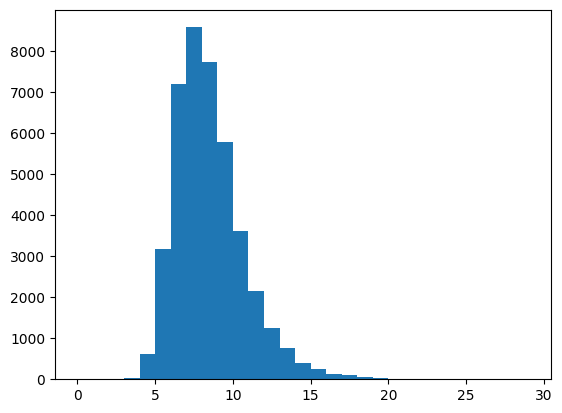

In [12]:
plt.hist([len(line) for line in eng_text], bins=range(0, 30, 1));

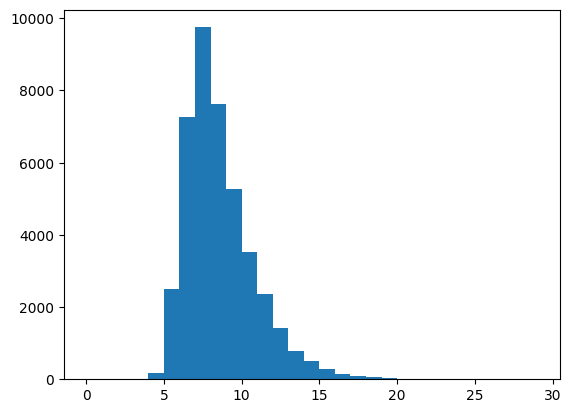

In [13]:
plt.hist([len(line) for line in ces_text], bins=range(0, 30, 1));

In [14]:
max([len(line) for line in eng_text])

36

In [15]:
max([len(line) for line in ces_text])

30

We observe that the vast majority of sequences contain fewer than 15 tokens. Hence, when creating the dataloaders, we will pad/truncate the sequences to this length. 

We are now ready to implement the vocabularies and the dataloaders. We will use the preprocessing steps we implemented thus far. Notice that since we are dealing with two languages, we will use two separate vocabularies. Other than that, our implementation is very similar to our previous ones; we just need to remember to shuffle the sequences before splitting them into the training and test sets. The outputs of each dataloader are batches of two sequences of token indices (corresponding to lines in both languages) and the unpadded length of the target sequence (excluding the *\<bos\>* token); we will need this value for computing the loss.

In [16]:
class Vocabulary: 

    def __init__(self, tokens=[], min_freq=0, reserved_tokens=[]):
        
        # Flatten the list of tokens
        if tokens and isinstance(tokens[0], list):
            tokens = [token for line in tokens for token in line]
        
        # Count token frequencies
        counter = collections.Counter(tokens)
        self.token_freqs = sorted(counter.items(), key=lambda x: x[1], reverse = True)

        # The list of unique tokens, we ignore tokens with frequency lower than min_freq
        self.idx_to_token = list(sorted(set(['<unk>'] + reserved_tokens + [token for token, freq in self.token_freqs if freq >= min_freq]))) 
        # convert tokens to indices
        self.token_to_idx = {token: idx for idx, token in enumerate(self.idx_to_token)}
     
    def __len__(self):
        return len(self.idx_to_token)
    
    def __getitem__(self, tokens):
        if not isinstance(tokens, (list, tuple)):
            return self.token_to_idx.get(tokens, self.unk) # return unknown token if not in the vocabulary
        return [self.__getitem__(token) for token in tokens]

    def to_tokens(self, indices):
        if hasattr(indices, '__len__') and len(indices) > 1:
            return [self.idx_to_token[int(index)] for index in indices]
        return self.idx_to_token[indices]
    
    @property
    def unk(self): # index for the unknown token
        return self.token_to_idx['<unk>']

In [17]:
class Tatoeba:

    def _preprocess(self, text):
        
        # Insert space between words and punctuation marks
        no_space = lambda char, prev_char: char in ',.!?' and prev_char != ' '
        out = [' ' + char if i > 0 and no_space(char, text[i - 1]) else char
               
               for i, char in enumerate(text.lower())]
        
        return ''.join(out)

    def truncate_pad(self, line, num_steps, padding_token):
        if len(line) > num_steps:
            return line[:num_steps]  # Truncate
        return line + [padding_token] * (num_steps - len(line))  # Pad
    
    def _read(self):
        
        data_dir = self.data_dir
        tatoeba_data = []
        
        with open(data_dir, encoding='utf-8') as file:
            lines = [line.rstrip() for line in file]

        for line in lines:
            line = _preprocess(line)
            idx = line.find("cc-by")
            tatoeba_data.append(line[:idx-1])
        
        lang1_text = []
        lang2_text = []
        
        for lines in tatoeba_data:
            words = lines.split('\t')
            
            if len(words) == 2:
                
                lang1_line = [t for t in f'{words[0]} <eos>'.split(' ') if t]
                lang2_line = [t for t in f'<bos> {words[1]} <eos>'.split(' ') if t]
                
                if len(lang1_line) > self.max_length + 1:
                    del lang1_line[self.max_length:-1]
                    
                if len(lang2_line) > self.max_length + 2:
                    del lang2_line[self.max_length+1:-1]
                    
                lang1_text.append(lang1_line)
                lang2_text.append(lang2_line)

        self.lang1_text = lang1_text
        self.lang2_text = lang2_text

    def _build(self):
        
        self._read()
        self.vocab_lang_1 = Vocabulary(self.lang1_text, min_freq = 2, reserved_tokens= ['<pad>'])
        self.vocab_lang_2 = Vocabulary(self.lang2_text, min_freq = 2, reserved_tokens= ['<pad>'])

        corpus_lang_1 = [self.vocab_lang_1[token] for token in self.lang1_text]
        corpus_lang_2 = [self.vocab_lang_2[token] for token in self.lang2_text]

        len_2 = torch.zeros(len(corpus_lang_2))
        for i in range(len(corpus_lang_2)):
            len_2[i] = len(corpus_lang_2[i])
            
        self.len_2 = len_2.long() - 1

        self.corpus_lang_1 = [self.truncate_pad(line, self.max_length + 1, self.vocab_lang_1['<pad>']) for line in corpus_lang_1]
        self.corpus_lang_2 = [self.truncate_pad(line, self.max_length + 2, self.vocab_lang_2['<pad>']) for line in corpus_lang_2]

        
        np.random.seed(0)
        rand_perm = np.random.permutation(range(len(self.corpus_lang_1))) 

        corpus_lang_1_train = [self.corpus_lang_1[i] for i in rand_perm[:self.num_train]]
        corpus_lang_2_train = [self.corpus_lang_2[i] for i in rand_perm[:self.num_train]]
        len_2_train = [self.len_2[i] for i in rand_perm[:self.num_train]]

        corpus_lang_1_test = [self.corpus_lang_1[i] for i in rand_perm[self.num_train:]]
        corpus_lang_2_test = [self.corpus_lang_2[i] for i in rand_perm[self.num_train:]]
        len_2_test = [self.len_2[i] for i in rand_perm[self.num_train:]]

        dataset_train = torch.utils.data.TensorDataset(*[torch.tensor(corpus_lang_1_train), torch.tensor(corpus_lang_2_train),len_2_train])
        dataset_test = torch.utils.data.TensorDataset(*[torch.tensor(corpus_lang_1_test), torch.tensor(corpus_lang_2_test),len_2_test])

        self.train_dataloader = torch.utils.data.DataLoader(dataset_train, self.batch_size, shuffle = True)
        self.test_dataloader = torch.utils.data.DataLoader(dataset_test, self.batch_size, shuffle = False)  


               
    def __init__(self, data_dir, num_train, batch_size, max_length):
        
        self.data_dir = data_dir
        self.num_train = num_train
        self.batch_size = batch_size
        self.max_length = max_length

        self._build()       

Let us check that our implementation works.

In [18]:
Tatoeba_dataset = Tatoeba('D:/nine circles 2/ces.txt', num_train = 38000, batch_size = 250, max_length = 15) 

We can directly access the lines in both languages as follows.

In [19]:
Tatoeba_dataset.lang1_text[5000]

['you', 'have', 'no', 'fever', '.', '<eos>']

In [20]:
Tatoeba_dataset.lang2_text[5000]

['<bos>', 'teplotu', 'nemáš', '.', '<eos>']

In [21]:
Tatoeba_dataset.len_2[5000]

tensor(4)

The corresponding token indices are as follows.

In [22]:
Tatoeba_dataset.corpus_lang_1[5000]

[5169, 2151, 3034, 1768, 24, 52, 53, 53, 53, 53, 53, 53, 53, 53, 53, 53]

In [23]:
Tatoeba_dataset.corpus_lang_2[5000]

[38, 7066, 3239, 17, 39, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40]

Lastly, let us check the dataloaders.

In [24]:
for X, Y, Y_len in Tatoeba_dataset.train_dataloader:
    print('X:', X, '\nY:', Y, '\nY_len:', Y_len)
    break

X: tensor([[2473, 2134, 4644,  ...,   53,   53,   53],
        [2311, 2152,  510,  ...,   53,   53,   53],
        [3997, 4954, 4644,  ...,   53,   53,   53],
        ...,
        [4658, 2097, 3034,  ...,   53,   53,   53],
        [2311, 2151, 5177,  ...,   53,   53,   53],
        [4658, 3968,   74,  ...,   52,   53,   53]]) 
Y: tensor([[  38, 1574, 7309,  ...,   40,   40,   40],
        [  38, 2961, 1699,  ...,   40,   40,   40],
        [  38,  506, 1660,  ...,   40,   40,   40],
        ...,
        [  38, 7124, 3242,  ...,   40,   40,   40],
        [  38, 2628, 7230,  ...,   40,   40,   40],
        [  38, 7124, 6182,  ...,   40,   40,   40]]) 
Y_len: tensor([10,  7,  5,  6,  9,  6,  6,  6, 11,  5,  4,  8, 13, 10,  4,  6,  8,  8,
         7,  7,  7,  7,  5, 10,  7,  7,  9,  7,  8,  9,  7, 11,  9,  5,  8, 12,
        12,  5, 10,  5, 11, 12,  5,  5,  5,  5,  6,  4,  7,  6,  9,  6,  9,  7,
        11,  5,  6,  5,  5,  6, 10,  9, 10,  8,  5,  7,  7,  6,  7, 11,  8,  7,
         4,  

In [25]:
for X, Y, Y_len in Tatoeba_dataset.test_dataloader:
    print('X:', X, '\nY:', Y, '\nY_len:', Y_len)
    break

X: tensor([[2311, 1413, 2570,  ...,   53,   53,   53],
        [ 564, 1813, 1515,  ...,   53,   53,   53],
        [1901,   21, 3034,  ...,   53,   53,   53],
        ...,
        [ 338, 1725,  338,  ...,   53,   53,   53],
        [1396, 5169, 1626,  ...,   53,   53,   53],
        [2311,  761, 3927,  ...,   53,   53,   53]]) 
Y: tensor([[  38, 4015, 3837,  ...,   40,   40,   40],
        [  38, 7704, 6085,  ...,   40,   40,   40],
        [  38, 2926, 2961,  ...,   40,   40,   40],
        ...,
        [  38, 4854, 8273,  ...,   40,   40,   40],
        [  38,  486, 6125,  ...,   40,   40,   40],
        [  38, 3821, 3603,  ...,   40,   40,   40]]) 
Y_len: tensor([ 6,  7,  6,  8,  6, 13,  7,  6,  7,  3,  7,  5,  4, 16,  4,  7,  9,  6,
         6,  7,  6,  6,  8,  5,  6,  7,  6,  5,  6,  9,  7,  5,  4,  7,  6,  5,
         8,  9,  7, 14,  7,  7,  9,  6,  8,  9,  8, 14, 10, 11,  5,  9,  7,  8,
         8,  7,  6, 10,  8,  8,  8,  6,  6,  6,  7,  6, 10,  6,  5,  7, 13,  6,
         7,  

## Encoder-Decoder Model <a class="anchor" id="encoder-decoder"></a>

As we have mentioned in the introduction,  the encoder-decoder architecture is used to solve sequence-to-sequence tasks such as machine translation . The encoder decoder architecture was originally proposed in [[1](#1), [2](#2)]. 

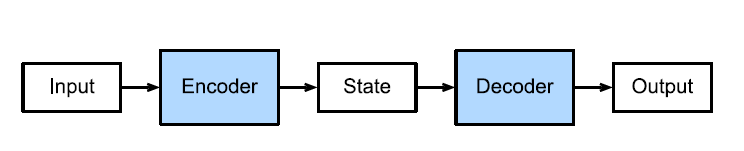

As shown in the sketch, we need to implement two main components: the encoder and the decoder. We will implement both of these as RNNs (specifically, we will use GRU instead of LSTM to make the implementation a bit simpler). 

The encoder RNN reads the English sequence, produces the output (we will simply use the current hidden state), and passes it to the decoder. The decoder uses this hidden state to generate a Czech sequence. Now, there are many ways to explicitly pass the hidden state from the encoder to the decoder. We will start with the simplest approach: treat the encoder and decoder as simple unidirectional RNNs of the same size. This means we can simply use the encoder's last hidden state as the decoder's initial hidden state.

Let us implement both the encoder and the decoder. The encoder is simply a GRU-based RNN with an embedding layer and no additional layers on the output. The decoder is also a GRU-based RNN with an embedding layer; however, it has an additional linear layer at the output to transform the recurrent block's outputs into probability logits for token predictions.

In [26]:
class Encoder(nn.Module): 
  
    def __init__(self, vocab_size, embed_size, hidden_size, num_layers, dropout = 0):
        super().__init__()

        self.vocab_size = vocab_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.rnn = nn.GRU(embed_size, hidden_size, num_layers, dropout = dropout)

    def forward(self, inputs):

        state = torch.zeros((self.num_layers, inputs.shape[0], self.hidden_size), device = inputs.device) 
        embeddings = self.embedding(inputs.T)
        
        outputs, state = self.rnn(embeddings, state)
        
        return outputs, state

In [27]:
class Decoder(nn.Module): 
  
    def __init__(self, vocab_size, embed_size, hidden_size, num_layers, dropout = 0):
        super().__init__()

        self.vocab_size = vocab_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.rnn = nn.GRU(embed_size, hidden_size, num_layers, dropout = dropout)
        self.linear = nn.Linear(hidden_size, vocab_size)

    def forward(self, inputs, state = None):

        embeddings = self.embedding(inputs.T)
        Y, state = self.rnn(embeddings, state)
        outputs = self.linear(Y)
        
        return outputs, state

One element that might not be clear is how the encoder-decoder network actually works. Since the decoder is an RNN, it also requires an input sequence, and so far, we have discussed only the transfer of the hidden state from the encoder to the decoder. Well, the computations within the encoder-decoder network will differ between training and prediction. Let us discuss training first.

### Training Encoder-Decoder Model <a class="anchor" id="training-encoder-decoder"></a>

During training, we will use the approach known as *teacher forcing* [[3](#3)]: in each step, the decoder is fed the correct Czech translation of the original English line. In other words, during training, the decoder performs a simple next-token prediction task on the Czech sequence, starting from the encoder's hidden state, which is a numerical representation of the original English line.

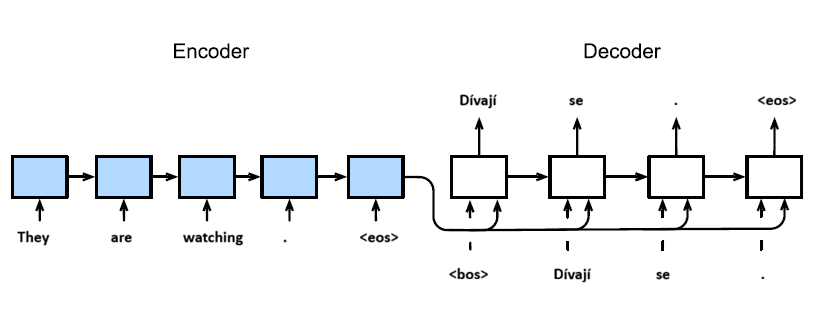

Hence, we get the following simple encoder-decoder architecture.

In [28]:
class Encoder_Decoder(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, num_layers, dropout = 0):
        super().__init__()

        self.encoder = Encoder(vocab_size[0], embed_size, hidden_size, num_layers, dropout = dropout)
        self.decoder = Decoder(vocab_size[1], embed_size, hidden_size, num_layers, dropout = dropout)

    def forward(self, input_X, input_Y):
        
        _ , state = self.encoder(input_X)
        output, _ = self.decoder(input_Y, state) 

        return output

Let us demonstrate the architecture on a single batch. The encoder-decoder takes two sequences as input. Notice that the target sequences (the Czech ones) are shortened by 1 element, because we are predicting the next token in a sequence and do not have a "next token" for the last Czech token. 

In [29]:
hidden_size = 256
num_layers = 2
vocab_size_1 = Tatoeba_dataset.vocab_lang_1.__len__()
vocab_size_2 = Tatoeba_dataset.vocab_lang_2.__len__()
embed_size = 128

encoder_decoder = Encoder_Decoder(hidden_size = hidden_size, num_layers = num_layers, vocab_size = [vocab_size_1, vocab_size_2], embed_size = 100)

for X, Y, Y_len in Tatoeba_dataset.train_dataloader:
    break

output = encoder_decoder(X, Y[:,:-1])
output

tensor([[[ 1.1635e-02, -9.6160e-02, -3.3850e-02,  ...,  4.3210e-03,
          -2.5020e-02, -1.5484e-01],
         [ 1.0208e-02, -1.0461e-01, -3.4470e-02,  ...,  1.2954e-03,
          -2.5322e-02, -1.5693e-01],
         [ 9.9812e-03, -1.0737e-01, -3.3934e-02,  ..., -2.7425e-03,
          -2.6317e-02, -1.6044e-01],
         ...,
         [ 1.1380e-02, -1.0425e-01, -3.4065e-02,  ...,  1.9812e-03,
          -2.7523e-02, -1.5680e-01],
         [ 1.1721e-02, -1.0517e-01, -3.3199e-02,  ..., -1.6982e-03,
          -2.6341e-02, -1.5924e-01],
         [ 1.1625e-02, -9.8003e-02, -3.8428e-02,  ..., -2.1029e-03,
          -2.6157e-02, -1.5486e-01]],

        [[-4.7667e-03, -1.1436e-01, -1.8214e-02,  ...,  1.0708e-01,
          -2.3502e-02, -1.0128e-01],
         [-5.9215e-03, -6.8421e-02, -3.4443e-03,  ...,  6.4420e-02,
           6.5148e-03, -1.1303e-01],
         [-5.4295e-02, -1.2677e-01, -1.0934e-02,  ...,  5.6994e-02,
          -6.8460e-02, -1.5988e-01],
         ...,
         [-5.7867e-03, -6

The outputs are probability logits for the next tokens in the sequence; we can use the usual cross-entropy loss between the logits and the original target sequence. This time, we shift the target sequence by one element, i.e., we ignore the first token (which is why we introduced the *\<bos\>* token; we need a token to initialize the first prediction).

In [30]:
output.size()

torch.Size([16, 250, 9634])

In [31]:
Y[:,1:].size()

torch.Size([250, 16])

In [32]:
cross_entropy_loss = nn.CrossEntropyLoss(reduction='mean')
cross_entropy_loss(output.permute(1, 2, 0), Y[:,1:])

tensor(9.2551, grad_fn=<NllLoss2DBackward0>)

One issue with this loss is that it includes the loss of padding token predictions, which are not that interesting (the translation task ends when the *'\<eos\>'* token is predicted). Consequently, we can ignore these parts of the sequences from the loss computations. To do so, we will define a custom *masked_loss*that ignores the "padded" parts in the calculations [[3](#3)].

In [33]:
def masked_loss(loss, Y_hat, Y, Y_len):
    
    loss_all = cross_entropy_loss(Y_hat, Y[:,1:])
    loss = 0

    for i in range(loss_all.size()[0]):
        loss = loss + (loss_all[i][:Y_len[i]]).mean()

    return loss/len(Y)

In [34]:
cross_entropy_loss = nn.CrossEntropyLoss(reduction='none')
loss = masked_loss(cross_entropy_loss, output.permute(1, 2, 0), Y, Y_len)
loss

tensor(9.1545, grad_fn=<DivBackward0>)

We can finally implement the train-test loop and use teacher forcing to train the model.

In [35]:
def train_test_loop_cuda(train_data_loader, test_data_loader, model, loss_fn, optimizer, scheduler, max_norm):
    
    softmax = torch.nn.Softmax(dim = 1)
    model.train()

    loss_sum_train  = 0
    size_train = 0

    
    for batch, (X, Y, Y_len) in enumerate(train_data_loader):

        X = X.to(cuda_device)
        Y = Y.to(cuda_device)
        Y_len = Y_len.to(cuda_device)

        optimizer.zero_grad() # zero out the gradients
        
        pred_logits = model(X, Y[:,:-1]) # forward pass
        loss = masked_loss(loss_fn, pred_logits.permute(1, 2, 0), Y, Y_len) # loss evaluation 
        #loss = loss_fn(pred_logits.permute(1, 2, 0), Y[:,1:]) # loss evaluation 

        # Backpropagation
        loss.backward() # gradient evaluation
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm = max_norm) # gradient clipping
        optimizer.step() # SGD step
        

        # compute prediction epoch loss and accuracy
        with torch.no_grad(): # we do not need to compute the gradients
            loss_sum_train = loss_sum_train + loss*len(X)
            size_train = size_train + len(X)
           
    # evaluate performance on the test set
    with torch.no_grad(): 
        
        loss_sum_train = loss_sum_train/size_train
        
        model.eval() 
        loss_sum_test  = 0
        size_test = 0
        
        for batch, (X_test, Y_test, Y_len_test) in enumerate(test_data_loader):

            state = None
            X_test = X_test.to(cuda_device)
            Y_test = Y_test.to(cuda_device)
            Y_len_test = Y_len.to(cuda_device)
            
            pred_logits_test = model(X_test, Y_test[:,:-1])
            
            loss_sum_test = loss_sum_test + masked_loss(loss_fn, pred_logits_test.permute(1, 2, 0), Y_test, Y_len_test)*len(X_test)
            #loss_sum_test = loss_sum_test + loss_fn(pred_logits_test.permute(1, 2, 0), Y_test[:,1:])*len(X_test)

            size_test = size_test + len(X_test)

        loss_sum_test = loss_sum_test/size_test
        
    # learning rate step; we use loss_sum_train for ReduceLROnPlateau
    learning_rate = scheduler.get_last_lr() 
    scheduler.step() 
    
    return  loss_sum_train.detach(), loss_sum_test.detach(), learning_rate[0]

Let us train the model on our dataset.

In [36]:
torch.manual_seed(123)

# data loader
Tatoeba_dataset = Tatoeba('D:/nine circles 2/ces.txt', num_train = 38000, batch_size = 250, max_length = 15) 
Tatoeba_train_loader = Tatoeba_dataset.train_dataloader
Tatoeba_test_loader = Tatoeba_dataset.test_dataloader

hidden_size = 256
num_layers = 2
vocab_size_1 = Tatoeba_dataset.vocab_lang_1.__len__()
vocab_size_2 = Tatoeba_dataset.vocab_lang_2.__len__()
embed_size = 256

encoder_decoder_cuda = Encoder_Decoder(hidden_size = hidden_size, num_layers = num_layers, vocab_size = [vocab_size_1, vocab_size_2], embed_size = 100).to(cuda_device)

optim_SGD_cuda =  torch.optim.SGD(encoder_decoder_cuda.parameters(), lr = 0.1, momentum = 0.9, weight_decay = 0.0001)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[200], gamma = 0.1)
cross_entropy_loss = nn.CrossEntropyLoss(reduction='none')
max_norm = 10

n_epochs = 300

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t]   = train_test_loop_cuda(Tatoeba_train_loader, Tatoeba_test_loader, encoder_decoder_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda, max_norm) 
end = time.time()
print(end - start)

3929.370537042618


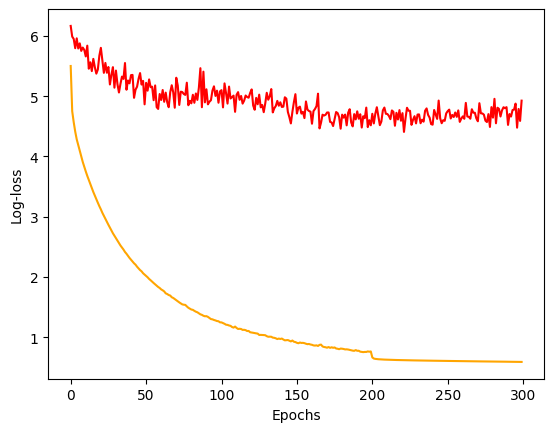

In [37]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

In [38]:
loss_epochs_train[299]

0.588495135307312

In [39]:
loss_epochs_test[299]

4.9263763427734375

In [40]:
loss_epochs_test.min()

4.407495975494385

Let us check the outputs of the model in the training "regime." We observe from the training loss that the model learned the training set pretty well.

In [41]:
torch.manual_seed(123)
for X_train, Y_train, Y_len in Tatoeba_dataset.train_dataloader:
    break

Tatoeba_dataset.vocab_lang_1.to_tokens(X_train[0][:6])   

['tom', 'has', 'denied', 'it', '.', '<eos>']

In [42]:
output = encoder_decoder_cuda(X_train[0][None,:].to(cuda_device), Y_train[0][None,:].to(cuda_device)).argmax(dim = 2)
Tatoeba_dataset.vocab_lang_2.to_tokens(output.flatten()[:5])

['tom', 'to', 'popřel', '.', '<eos>']

In [43]:
Tatoeba_dataset.vocab_lang_2.to_tokens(Y_train[0][:6])

['<bos>', 'tom', 'to', 'popřel', '.', '<eos>']

We observe that when the encoder's hidden state and the correct Czech translation are fed into the encoder, we obtain the correct output. 

The loss on the test is significantly higher; hence, we expect that the model performs much worse.

In [44]:
torch.manual_seed(123)
for X_test, Y_test, Y_len in Tatoeba_dataset.test_dataloader:
    break

Tatoeba_dataset.vocab_lang_1.to_tokens(X_test[0][:8])   

['i', "don't", 'know', 'anything', 'about', 'anything', '.', '<eos>']

In [45]:
output = encoder_decoder_cuda(X_test[0][None,:].to(cuda_device), Y_test[0][None,:].to(cuda_device)).argmax(dim = 2)
Tatoeba_dataset.vocab_lang_2.to_tokens(output.flatten()[:6])

['nic', 'nic', 'nic', '.', '.', '<eos>']

In [46]:
Tatoeba_dataset.vocab_lang_2.to_tokens(Y_test[0][:6])

['<bos>', 'o', 'ničem', 'nic', 'nevím', '.']

We observe that this model's output is indeed much worse than the prediction; essentially, it reads "nothing nothing..". 

However, these model outputs are not particularly interesting overall, since we are still feeding the correct Czech translations into the model in each step. To better evaluate the performance, we need to check the model's predictions when the original English sentence is known.

### Computing Predictions <a class="anchor" id="predictions"></a>

Let us now look at ways to obtain predictions from our encoder-decoder model. The main difference from training mode, where we fed the correct Czech sentence into the decoder, is that we will now use the decoder's predicted outputs from the previous steps as inputs for the next steps.   

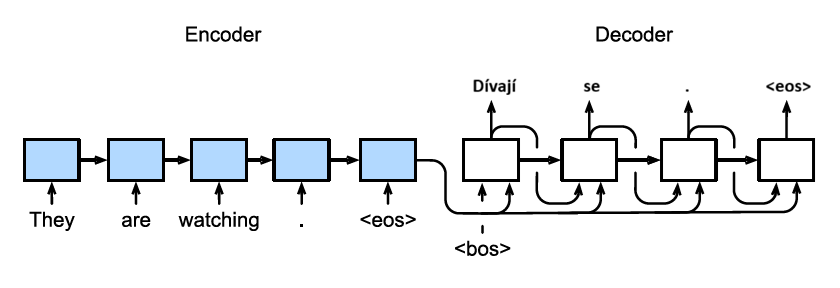

The simplest strategy to get the predictions is just to always pick the next most probable token in the sequence; we will call this algorithm *greedy*.

In [47]:
def predict_greedy(model, input_X, input_Y_init, num_steps):

        input_Y = input_Y_init
        prefix = input_Y_init
        _ , state = model.encoder(input_X)
        
        for i in range(num_steps): 
    
            output, state = model.decoder(input_Y, state)
            input_Y = output.argmax()[None][None]
            prefix = torch.cat((prefix,input_Y),0)

        return prefix.flatten()

In [48]:
bos_token = torch.tensor(Tatoeba_dataset.vocab_lang_2['<bos>'])
bos_token = bos_token[None][None]

greedy_pred = predict_greedy(encoder_decoder_cuda, X_train[0][None,:].to(cuda_device), bos_token.to(cuda_device), 10)
Tatoeba_dataset.vocab_lang_2.to_tokens(greedy_pred)

['<bos>',
 'tom',
 'to',
 'popřel',
 '.',
 '<eos>',
 '<eos>',
 '.',
 '<eos>',
 '<eos>',
 '.']

For our example in the training set, we get the exact translation. The translation of the second sentence from the test set ("I don't know anything about anything.") reads word for word "nothing about I don't know don't know", i.e., the translation based on the greedy algorithm is pretty bad. Let us try to do a bit better.

In [49]:
bos_token = torch.tensor(Tatoeba_dataset.vocab_lang_2['<bos>'])
bos_token = bos_token[None][None]

greedy_pred = predict_greedy(encoder_decoder_cuda, X_test[0][None,:].to(cuda_device), bos_token.to(cuda_device), 10)
Tatoeba_dataset.vocab_lang_2.to_tokens(greedy_pred)

['<bos>',
 'nic',
 'o',
 'nevím',
 'nevím',
 '.',
 '<eos>',
 '<eos>',
 '<eos>',
 '<eos>',
 '<eos>']

The issue with the greedy strategy is that even though we always pick the most probable next token in the sequence, that does not mean that the whole sequence is the most probable overall according to our model. Ideally, we would perform an exhaustive search, feeding the model all possible sequences and obtaining the corresponding predicted probabilities. However, this approach becomes computationally intractable after just a few steps, even with a modestly large token vocabulary.

Hence, we use a compromise known as the *beam search* [[3](#3)]. The code of the beam search algorithm might look a bit complicated, but the concept is very simple. In each step, the beam search keeps the history of a given number of the most probable sequences (*beam_size*) and explores expansions of those (the figure from [[3](#3)] shows the beam search for *beam_size* = 2). Note that the beam search becomes the greedy search for *beam_size* = 1.

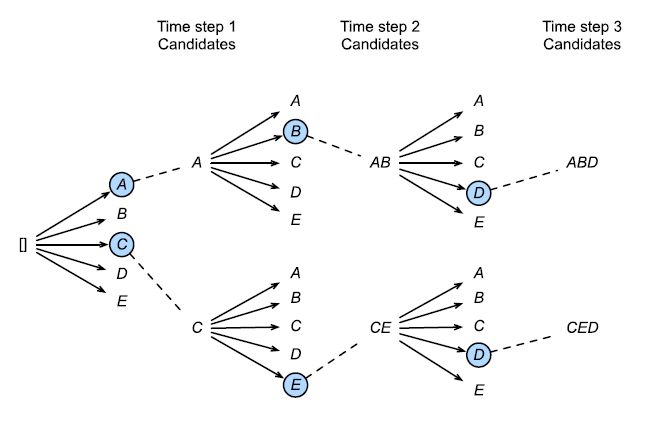

In [50]:
def predict_beam(model, input_X, input_Y_init, num_steps, beam_size):

        with torch.no_grad():
            
            input_Y = input_Y_init
            prefix = input_Y_init
            _ , state = model.encoder(input_X)
            output, state = model.decoder(input_Y, state)

            sort_by_prob = torch.sort(torch.nn.functional.softmax(output.flatten(), dim = 0),descending  = True)
                
            # predicted sequences
            pred_token_seq = torch.zeros([beam_size, num_steps], device = input_X.device).long() 
            pred_token_seq[:,0] = sort_by_prob[1][:beam_size]

            # probabilities
            prob_seq = sort_by_prob[0][:beam_size]

            # hidden states             
            hidden_states_seq = state.repeat([1,beam_size,1])
            
            for i in range(1, num_steps):
            
                outputs, states = model.decoder(pred_token_seq[:,i-1].reshape([beam_size,1]), hidden_states_seq)

                pred_token_seq_new = torch.zeros([beam_size, num_steps], device = input_X.device).long() 

                output_0_sort_by_prob = torch.sort(torch.nn.functional.softmax(outputs[:,0,:].flatten(), dim = 0),descending  = True)

                pred_token_seq_new[:,0:i] =  pred_token_seq[0,0:i]
                pred_token_seq_new[:,i] = output_0_sort_by_prob[1][:beam_size]
                
                prob_seq_new = prob_seq[0]*output_0_sort_by_prob[0][:beam_size]
                hidden_states_seq = states[:,0,:][:,None,:].repeat([1,beam_size,1])

                for j in range(1, beam_size):
                
                    output_j_sort_by_prob = torch.sort(torch.nn.functional.softmax(outputs[:,j,:].flatten(), dim = 0),descending  = True)

                    for k in range(beam_size):

                        prob_cand = prob_seq[j]*output_j_sort_by_prob[0][k]
                    
                        for l in range(beam_size):
                        
                            if prob_cand > prob_seq_new[l]:
                                prob_seq_new[l] = prob_cand
                                pred_token_seq_new[l,0:i] = pred_token_seq[j,0:i]
                                pred_token_seq_new[l,i] = output_j_sort_by_prob[1][k]
                                hidden_states_seq[:,l,:] = states[:,j,:]
                                break

                        if (l == beam_size):
                            break
                            
                prob_seq = prob_seq_new
                pred_token_seq = pred_token_seq_new
                
        # return outputs, states
        return pred_token_seq, prob_seq 

As we have mentioned earlier, the beam search reduces to the greedy search for *beam_size* = 1.

In [51]:
pred_token_seq, prob_pred = predict_beam(encoder_decoder_cuda, X_test[0][None,:].to(cuda_device), bos_token.to(cuda_device), num_steps = 5, beam_size = 1)
Tatoeba_dataset.vocab_lang_2.to_tokens(pred_token_seq[0])

['nic', 'o', 'nevím', 'nevím', '.']

Let us try increasing the *beam_size* to hopefully get a better translation.

In [52]:
pred_token_seq, prob_pred = predict_beam(encoder_decoder_cuda, X_test[0][None,:].to(cuda_device), bos_token.to(cuda_device), num_steps = 5, beam_size = 20)
pred_token_seq

tensor([[3821, 4015, 3662, 3662,   17],
        [3821, 4015, 4000, 3662,   17],
        [3821, 4015, 4564, 3662,   17],
        [3821, 4015, 7115, 3662,   17],
        [3821, 4015, 9295, 3662,   17],
        [3821, 4015, 2980, 3662,   17],
        [8424, 3821, 3662,   17,   39],
        [3821, 4015, 3822, 3662,   17],
        [3821, 4015, 2441, 3662,   17],
        [3821, 4015, 9267, 3662,   17],
        [3821, 3662, 7117,   17,   39],
        [3821, 4015,  585, 3662,   17],
        [3821, 4015, 3822, 2980,   17],
        [3821, 4015, 4564, 3603,   17],
        [3821, 4015, 4564, 8273,   17],
        [3821, 4015, 8408, 2980,   17],
        [3821, 3662, 4015, 4564,   17],
        [3821, 4015, 2980, 2980,   17],
        [3821, 3662, 4015, 3662, 8350],
        [3821, 3662, 4015, 3662, 2980]], device='cuda:0')

Predicted seqeunce probabilities are as follows.

In [53]:
prob_pred

tensor([6.1189e-02, 5.9911e-02, 2.5498e-02, 2.3897e-02, 2.1389e-02, 1.6255e-02,
        1.3434e-02, 7.5123e-03, 6.7096e-03, 5.8754e-03, 5.6444e-03, 3.5407e-03,
        4.2972e-04, 4.0896e-04, 3.9204e-04, 3.6038e-04, 3.2664e-04, 2.8572e-04,
        4.0786e-05, 4.0162e-05], device='cuda:0')

In this case, we got the same result.

In [54]:
Tatoeba_dataset.vocab_lang_2.to_tokens(pred_token_seq[0])

['nic', 'o', 'nevím', 'nevím', '.']

Let us show another example.

In [55]:
Tatoeba_dataset.vocab_lang_1.to_tokens(X_test[4][:8])

['tom', 'was', 'waiting', 'for', 'a', 'train', '.', '<eos>']

In [56]:
greedy_pred = predict_greedy(encoder_decoder_cuda, X_test[4][None,:].to(cuda_device), bos_token.to(cuda_device), 10)
Tatoeba_dataset.vocab_lang_2.to_tokens(greedy_pred)

['<bos>',
 'tom',
 'čekal',
 'v',
 'zoo',
 '.',
 '<eos>',
 '<eos>',
 '<eos>',
 '.',
 '<eos>']

The greedy prediction "hallucinated" a bit; it reads: "Tom was waiting in a zoo." 

In [57]:
pred_token_seq, prob_pred = predict_beam(encoder_decoder_cuda, X_test[4][None,:].to(cuda_device), bos_token.to(cuda_device), num_steps = 10, beam_size = 20)
Tatoeba_dataset.vocab_lang_2.to_tokens(pred_token_seq[0])

['tom', 'čekal', 'vlak', '.', '<eos>', '<eos>', '.', '<eos>', '<eos>', '<eos>']

Beam search is much better; the translation is almost correct, it just missed the preposition; it should be "Tom čekal *na* vlak." Let us try another example.

In [58]:
Tatoeba_dataset.vocab_lang_1.to_tokens(X_test[3][:9])

['i', 'wish', 'i', "could've", 'gone', 'with', 'you', '.', '<eos>']

In [59]:
greedy_pred = predict_greedy(encoder_decoder_cuda, X_test[3][None,:].to(cuda_device), bos_token.to(cuda_device), 10)
Tatoeba_dataset.vocab_lang_2.to_tokens(greedy_pred)

['<bos>',
 'kéž',
 'bych',
 'si',
 'mohl',
 'jít',
 's',
 'tebou',
 '.',
 '<eos>',
 '<eos>']

The greedy prediction is a bit of a mess; it almost reads (it is also grammatically wrong) as "I wish you could have gone with you." 

In [60]:
pred_token_seq, prob_pred = predict_beam(encoder_decoder_cuda, X_test[3][None,:].to(cuda_device), bos_token.to(cuda_device), num_steps = 10, beam_size = 10)
Tatoeba_dataset.vocab_lang_2.to_tokens(pred_token_seq[0])

['kéž', 'bych', 'tam', 'mohl', 'být', 's', 'tebou', '.', '<eos>', '<eos>']

The beam search translation is much better: "I wish I could have been with you." The meaning is shifted a bit, but not by much. By the way, the accurate translation is as follows.

In [61]:
Tatoeba_dataset.vocab_lang_2.to_tokens(Y_test[3][:9])

['<bos>', 'kéž', 'bych', 'byl', 'šel', 's', 'tebou', '.', '<eos>']

### BLEU <a class="anchor" id="bleu"></a>

From our examples, we observe that evaluating translation accuracy can be a bit involved.  A popular similarity measure between two sequences is Bilingual Evaluation Understudy (BLEU). The BLEU score is defined as 
$$\text{BLEU} = \text{exp}\left(\text{min}\left(0, 1 - \frac{l_\mathrm{target}}{l_\mathrm{pred}}\right)\right) \prod_{i=1}^{N} p_i^{1/2^{i}},$$
where $l_\mathrm{pred}$ is the length of the predicted sequence,  $l_\mathrm{target}$ is the length of the target sequence, and $p_i$ is the proportion of the correct $i$-grams in the predicted sequence, which are computed up to a given fixed order $N$ (usually $N \leq 4$) [[3](#3)]. 

In [62]:
import math
def BLEU(pred_tokens, label_tokens, k): 

    len_pred, len_label = len(pred_tokens), len(label_tokens)
    score = math.exp(min(0, 1 - len_label / len_pred))
    
    for n in range(1, min(k, len_pred) + 1):
        num_matches, label_subs = 0, collections.defaultdict(int)
        for i in range(len_label - n + 1):
            label_subs[' '.join(label_tokens[i: i + n])] += 1
        for i in range(len_pred - n + 1):
            if label_subs[' '.join(pred_tokens[i: i + n])] > 0:
                num_matches += 1
                label_subs[' '.join(pred_tokens[i: i + n])] -= 1
    score *= math.pow(num_matches / (len_pred - n + 1), math.pow(0.5, n))
    return score

For perfect trasnaltion, the BLEU score equals one.

In [63]:
pred_token_seq, prob_pred = predict_beam(encoder_decoder_cuda, X_train[0][None,:].to(cuda_device), bos_token.to(cuda_device), num_steps = 10, beam_size = 10)
Tatoeba_dataset.vocab_lang_2.to_tokens(pred_token_seq[0])[:4]

['tom', 'to', 'popřel', '.']

In [64]:
Tatoeba_dataset.vocab_lang_2.to_tokens(Y_train[0][1:5])

['tom', 'to', 'popřel', '.']

In [65]:
BLEU(Tatoeba_dataset.vocab_lang_2.to_tokens(pred_token_seq[0][:4]), Tatoeba_dataset.vocab_lang_2.to_tokens(Y_train[0][1:5]), 4)

1.0

Provided that there is no exact $N$-gram in the translation in comparison to the reference, the BLEU score is zero.

In [66]:
pred_token_seq, prob_pred = predict_beam(encoder_decoder_cuda, X_test[0][None,:].to(cuda_device), bos_token.to(cuda_device), num_steps = 10, beam_size = 10)
Tatoeba_dataset.vocab_lang_2.to_tokens(pred_token_seq[0])[:5]

['nic', 'o', 'něm', 'nevím', '.']

In [67]:
Tatoeba_dataset.vocab_lang_2.to_tokens(Y_test[0][1:6])

['o', 'ničem', 'nic', 'nevím', '.']

In [68]:
BLEU(Tatoeba_dataset.vocab_lang_2.to_tokens(pred_token_seq[0][:5]), Tatoeba_dataset.vocab_lang_2.to_tokens(Y_test[0][1:6]), 4)

0.0

Indeed, we observe that we get a non-zero BLEU value, provided that we reduce $N$.

In [69]:
BLEU(Tatoeba_dataset.vocab_lang_2.to_tokens(pred_token_seq[0][:5]), Tatoeba_dataset.vocab_lang_2.to_tokens(Y_test[0][1:6]), 2)

0.7071067811865476

One issue with BLEU is that it just compares $N$-grams, not the actual meaning; hence, the following translation gets a zero score even though we discussed that the translation is actually pretty close to the actual meaning. 

In [70]:
pred_token_seq, prob_pred = predict_beam(encoder_decoder_cuda, X_test[3][None,:].to(cuda_device), bos_token.to(cuda_device), num_steps = 10, beam_size = 10)
Tatoeba_dataset.vocab_lang_2.to_tokens(pred_token_seq[0])[:8]

['kéž', 'bych', 'tam', 'mohl', 'být', 's', 'tebou', '.']

In [71]:
Tatoeba_dataset.vocab_lang_2.to_tokens(Y_test[3][1:8])

['kéž', 'bych', 'byl', 'šel', 's', 'tebou', '.']

In [72]:
BLEU(Tatoeba_dataset.vocab_lang_2.to_tokens(pred_token_seq[0])[:8], Tatoeba_dataset.vocab_lang_2.to_tokens(Y_test[3][1:8]), 4)

0.0

In [73]:
BLEU(Tatoeba_dataset.vocab_lang_2.to_tokens(pred_token_seq[0])[:8], Tatoeba_dataset.vocab_lang_2.to_tokens(Y_test[3][1:8]), 3)

0.7993391672164404

Let us compute the overall BLE score for the test set (with $N = 3$).

In [75]:
bleu_score = []

for X, Y, Y_len in Tatoeba_dataset.test_dataloader:
    
    for i in range(len(X)):
        
        pred_token_seq, _ = predict_beam(encoder_decoder_cuda, X[i][None,:].to(cuda_device), bos_token.to(cuda_device), num_steps = 10, beam_size = 5)
        pred_token_seq = Tatoeba_dataset.vocab_lang_2.to_tokens(pred_token_seq[0])
        
        try:
            idx = pred_token_seq.index('<eos>')
        except:
            idx = len(pred_token_seq)
            
        pred_token_seq = pred_token_seq[:idx]
        if len(pred_token_seq) > 0:
            bleu_score.append(BLEU(pred_token_seq, Tatoeba_dataset.vocab_lang_2.to_tokens(Y[i][1:Y_len[i]]), 3))
        else:
            bleu_score.append(0)

In [76]:
sum(bleu_score)/len(bleu_score)

0.2236413123453665

### Advanced Encoder-Decoder Model <a class="anchor" id="advanced"></a>

In previous parts, we implemented a simple encoder-decoder model in which we passed the encoder's hidden state directly to the decoder. We should note that this requires both RNNs to be identical. 

Let us try something more involved. Instead of just passing the hidden states, we will also add their values to the decoder's input, i.e., the previous token of the translated sequence concatenated with the encoder's hidden state. This ensures that the so-called *context* of the original English sentence is always available to the encoder and cannot be lost as the translation progresses.

Let us demonstrate the new evaluation.

In [77]:
hidden_size = 256
num_layers = 2
vocab_size_1 = Tatoeba_dataset.vocab_lang_1.__len__()
embed_size = 128

encoder = Encoder(hidden_size = hidden_size, num_layers = num_layers, vocab_size = vocab_size_1, embed_size = embed_size)
encoder

Encoder(
  (embedding): Embedding(5186, 128)
  (rnn): GRU(128, 256, num_layers=2)
)

In [78]:
for X, Y, Y_len in Tatoeba_dataset.train_dataloader:
    break
    
_, state = encoder(X)

The context obtained from the encoder is as follows.

In [79]:
context = state
context.size()

torch.Size([2, 250, 256])

In [80]:
vocab_size_2 = Tatoeba_dataset.vocab_lang_2.__len__()

embedding_decoder = nn.Embedding(vocab_size_2, embed_size)
rnn_decoder = nn.RNN(embed_size + num_layers*hidden_size, hidden_size, num_layers)
linear_decoder = nn.Linear(hidden_size, vocab_size_2)

We need to add context to the decoder's input sequence.

In [81]:
context_reshaped = torch.cat(context.permute(0, 2, 1).unbind(dim = 0)).unsqueeze(0).permute(0, 2, 1)
context_reshaped.size()

torch.Size([1, 250, 512])

Let us make sure we have correctly reshaped the context vectors.

In [82]:
context_reshaped[:,100,:] - torch.cat([context[0,100,:], context[1,100,:]])

tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.

Lastly, we simply concatenate the context with the embeddings. Then we can obtain the decoder's output.

In [83]:
Y_embdedding =  embedding_decoder(Y.T)
Y_embdedding.size()

torch.Size([17, 250, 128])

In [84]:
context_broadcast = context_reshaped.repeat(Y_embdedding.shape[0], 1, 1)
context_broadcast.size()

torch.Size([17, 250, 512])

In [85]:
emb_cont = torch.cat((Y_embdedding, context_broadcast), -1)
emb_cont.size()

torch.Size([17, 250, 640])

In [86]:
output, state = rnn_decoder(emb_cont, state)
output.size()

torch.Size([17, 250, 256])

Overall, we get the following modified encoder-decoder model (we will also pass the hidden states as in the previous implementation).

In [87]:
class Decoder_2(nn.Module):

    def __init__(self, vocab_size, embed_size, hidden_size, num_layers, dropout = 0):
        super().__init__()

        self.vocab_size = vocab_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.rnn = nn.GRU(embed_size + num_layers*hidden_size, hidden_size, num_layers, dropout = dropout)
        self.linear = nn.Linear(hidden_size, vocab_size)
        
    def forward(self, inputs, st_cont):

        state = st_cont[0]
        context = st_cont[1]
        
        embeddings = self.embedding(inputs.T)
        context_broadcast = context.repeat(embeddings.shape[0], 1, 1)
        emb_cont = torch.cat((embeddings, context_broadcast), -1)
        
        Y, state = self.rnn(emb_cont, state)
        outputs = self.linear(Y)
        
        return outputs, state

In [88]:
class Encoder_Decoder_2(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, num_layers, dropout = 0):
        super().__init__()

        self.encoder = Encoder(vocab_size[0], embed_size, hidden_size, num_layers, dropout = dropout)
        self.decoder = Decoder_2(vocab_size[1], embed_size, hidden_size, num_layers, dropout = dropout)

    def forward(self, input_X, input_Y):
        
        _ , state = self.encoder(input_X)

        context = state
        context_reshaped = torch.cat(context.permute(0, 2, 1).unbind(dim = 0)).unsqueeze(0).permute(0, 2, 1)
        
        output, state = self.decoder(input_Y, [state, context_reshaped]) 
        
        return output

Let us train the model.

In [94]:
torch.manual_seed(123)

# data loader
Tatoeba_dataset = Tatoeba('D:/nine circles 2/ces.txt', num_train = 38000, batch_size = 250, max_length = 15) 
Tatoeba_train_loader = Tatoeba_dataset.train_dataloader
Tatoeba_test_loader = Tatoeba_dataset.test_dataloader

hidden_size = 256
num_layers = 2
vocab_size_1 = Tatoeba_dataset.vocab_lang_1.__len__()
vocab_size_2 = Tatoeba_dataset.vocab_lang_2.__len__()
embed_size = 256

encoder_decoder_cuda = Encoder_Decoder_2(hidden_size = hidden_size, num_layers = num_layers, vocab_size = [vocab_size_1, vocab_size_2], embed_size = 100).to(cuda_device)

optim_SGD_cuda =  torch.optim.SGD(encoder_decoder_cuda.parameters(), lr = 0.1, momentum = 0.9, weight_decay = 0)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[150], gamma = 0.1)
cross_entropy_loss = nn.CrossEntropyLoss(reduction='none')
max_norm = 10

n_epochs = 300

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t]   = train_test_loop_cuda(Tatoeba_train_loader, Tatoeba_test_loader, encoder_decoder_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda, max_norm) 
end = time.time()
print(end - start)

3915.5439512729645


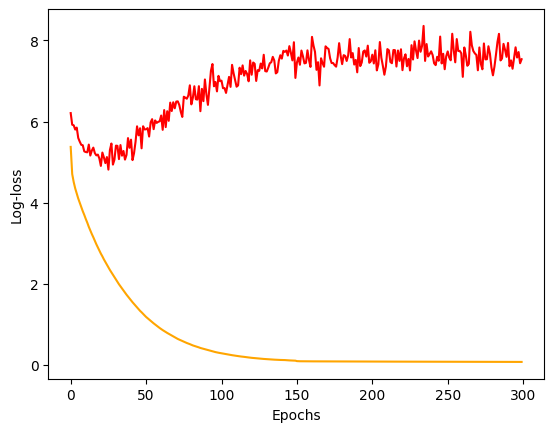

In [95]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

In [96]:
loss_epochs_train[299]

0.07325021922588348

In [97]:
loss_epochs_test[299]

7.536616325378418

In [98]:
loss_epochs_test.min()

4.814748287200928

We observe that the training loss reached zero; however, the test loss is worse. Indeed, while the predictions on the train set seem perfect

In [99]:
output = encoder_decoder_cuda(X_train[0][None,:].to(cuda_device), Y_train[0][None,:].to(cuda_device)).argmax(dim = 2)
Tatoeba_dataset.vocab_lang_2.to_tokens(output.flatten()[:5])

['tom', 'to', 'popřel', '.', '<eos>']

In [100]:
Tatoeba_dataset.vocab_lang_2.to_tokens(Y_train[0][:6])

['<bos>', 'tom', 'to', 'popřel', '.', '<eos>']

we again observe that the predictions on the test set are lacking.

In [101]:
output = encoder_decoder_cuda(X_test[0][None,:].to(cuda_device), Y_test[0][None,:].to(cuda_device)).argmax(dim = 2)
Tatoeba_dataset.vocab_lang_2.to_tokens(output.flatten()[:6])

['nic', 'nic', 'nic', 'nevím', '.', '<eos>']

In [102]:
Tatoeba_dataset.vocab_lang_2.to_tokens(Y_test[0][:6])

['<bos>', 'o', 'ničem', 'nic', 'nevím', '.']

Let us check the predictions.

In [103]:
def predict_greedy_2(model, input_X, input_Y_init, num_steps):

        input_Y = input_Y_init
        prefix = input_Y_init
        _ , state = model.encoder(input_X)

        context = state
        context_reshaped = torch.cat(context.permute(0, 2, 1).unbind(dim = 0)).unsqueeze(0).permute(0, 2, 1)


        for i in range(num_steps): 
    
            output, state = model.decoder(input_Y, [state, context_reshaped])
            input_Y = output.argmax()[None][None]
            prefix = torch.cat((prefix,input_Y),0)

        return prefix.flatten()

In [104]:
bos_token = torch.tensor(Tatoeba_dataset.vocab_lang_2['<bos>'])
bos_token = bos_token[None][None]

greedy_pred = predict_greedy_2(encoder_decoder_cuda, X_train[0][None,:].to(cuda_device), bos_token.to(cuda_device), 10)
Tatoeba_dataset.vocab_lang_2.to_tokens(greedy_pred)

['<bos>', 'tom', 'to', 'popřel', '.', '<eos>', '.', '<eos>', '.', '<eos>', '.']

In [105]:
def predict_beam_2(model, input_X, input_Y_init, num_steps, beam_size):

        with torch.no_grad():
            
            input_Y = input_Y_init
            prefix = input_Y_init
            _ , state = model.encoder(input_X)

            context = state
            context_reshaped = torch.cat(context.permute(0, 2, 1).unbind(dim = 0)).unsqueeze(0).permute(0, 2, 1)
    
            output, state = model.decoder(input_Y, [state, context_reshaped])

            sort_by_prob = torch.sort(torch.nn.functional.softmax(output.flatten(), dim = 0),descending  = True)
                
            # predicted sequences
            pred_token_seq = torch.zeros([beam_size, num_steps], device = input_X.device).long() 
            pred_token_seq[:,0] = sort_by_prob[1][:beam_size]

            # probabilities
            prob_seq = sort_by_prob[0][:beam_size]

            # hidden states             
            hidden_states_seq = state.repeat([1,beam_size,1])
            
            for i in range(1, num_steps):
            
                outputs, states = model.decoder(pred_token_seq[:,i-1].reshape([beam_size,1]), [hidden_states_seq, context_reshaped.repeat([1,beam_size,1])])

                pred_token_seq_new = torch.zeros([beam_size, num_steps], device = input_X.device).long() 

                output_0_sort_by_prob = torch.sort(torch.nn.functional.softmax(outputs[:,0,:].flatten(), dim = 0),descending  = True)

                pred_token_seq_new[:,0:i] =  pred_token_seq[0,0:i]
                pred_token_seq_new[:,i] = output_0_sort_by_prob[1][:beam_size]
                
                prob_seq_new = prob_seq[0]*output_0_sort_by_prob[0][:beam_size]
                hidden_states_seq = states[:,0,:][:,None,:].repeat([1,beam_size,1])

                for j in range(1, beam_size):
                
                    output_j_sort_by_prob = torch.sort(torch.nn.functional.softmax(outputs[:,j,:].flatten(), dim = 0),descending  = True)

                    for k in range(beam_size):

                        prob_cand = prob_seq[j]*output_j_sort_by_prob[0][k]
                    
                        for l in range(beam_size):
                        
                            if prob_cand > prob_seq_new[l]:
                                prob_seq_new[l] = prob_cand
                                pred_token_seq_new[l,0:i] = pred_token_seq[j,0:i]
                                pred_token_seq_new[l,i] = output_j_sort_by_prob[1][k]
                                hidden_states_seq[:,l,:] = states[:,j,:]
                                break

                        if (l == beam_size):
                            break
                            
                prob_seq = prob_seq_new
                pred_token_seq = pred_token_seq_new
                
        # return outputs, states
        return pred_token_seq, prob_seq 

The predictions of our new model are very similar to those of our simpler model. Actually, looking at the ones we have investigated previously,  these seem even weaker. The first translation is a bit shifted in the meaning; it reads "I don't know anything about him," instead of "I don't know anything about anything." 

In [106]:
pred_token_seq, prob_pred = predict_beam_2(encoder_decoder_cuda, X_test[0][None,:].to(cuda_device), bos_token.to(cuda_device), num_steps = 5, beam_size = 10)
Tatoeba_dataset.vocab_lang_2.to_tokens(pred_token_seq[0])

['nic', 'o', 'něm', 'nevím', '.']

The second translation (both for greedy and beam search) is worse in this model. We again observe the slight shift from "go" to "be"; however, there is also a nonsensical continuation "something \<unk\>" at the end of the sequence.

In [107]:
pred_token_seq, prob_pred = predict_beam_2(encoder_decoder_cuda, X_test[3][None,:].to(cuda_device), bos_token.to(cuda_device), num_steps = 10, beam_size = 1)
Tatoeba_dataset.vocab_lang_2.to_tokens(pred_token_seq[0])[:9]

['kéž', 'bych', 'byl', 's', 'tebou', 'něco', '<unk>', '.', '<eos>']

In [108]:
pred_token_seq, prob_pred = predict_beam_2(encoder_decoder_cuda, X_test[3][None,:].to(cuda_device), bos_token.to(cuda_device), num_steps = 10, beam_size = 10)
Tatoeba_dataset.vocab_lang_2.to_tokens(pred_token_seq[0])[:9]

['kéž', 'bych', 'byl', 's', 'tebou', 'něco', '<unk>', '.', '<eos>']

We can observe that the model is indeed a bit weaker by computing the BLEU score.

In [109]:
bleu_score = []

for X, Y, Y_len in Tatoeba_dataset.test_dataloader:
    
    for i in range(len(X)):
        
        pred_token_seq, _ = predict_beam_2(encoder_decoder_cuda, X[i][None,:].to(cuda_device), bos_token.to(cuda_device), num_steps = 10, beam_size = 5)
        pred_token_seq = Tatoeba_dataset.vocab_lang_2.to_tokens(pred_token_seq[0])
        
        try:
            idx = pred_token_seq.index('<eos>')
        except:
            idx = len(pred_token_seq)
            
        pred_token_seq = pred_token_seq[:idx]
        if len(pred_token_seq) > 0:
            bleu_score.append(BLEU(pred_token_seq, Tatoeba_dataset.vocab_lang_2.to_tokens(Y[i][1:Y_len[i]]), 3))
        else:
            bleu_score.append(0)

In [110]:
sum(bleu_score)/len(bleu_score)

0.20515852010435653

Indeed, the score is a bit worse than the 0.2236 we obtained earlier.

Let us regularize the training loop to improve the model's generalizability.

In [111]:
torch.manual_seed(123)

# data loader
Tatoeba_dataset = Tatoeba('D:/nine circles 2/ces.txt', num_train = 38000, batch_size = 250, max_length = 15) 
Tatoeba_train_loader = Tatoeba_dataset.train_dataloader
Tatoeba_test_loader = Tatoeba_dataset.test_dataloader

hidden_size = 256
num_layers = 2
vocab_size_1 = Tatoeba_dataset.vocab_lang_1.__len__()
vocab_size_2 = Tatoeba_dataset.vocab_lang_2.__len__()
embed_size = 256

encoder_decoder_cuda = Encoder_Decoder_2(hidden_size = hidden_size, num_layers = num_layers, vocab_size = [vocab_size_1, vocab_size_2], embed_size = 100, dropout = 0.2).to(cuda_device)

optim_SGD_cuda =  torch.optim.SGD(encoder_decoder_cuda.parameters(), lr = 0.1, momentum = 0.9, weight_decay = 0.0001)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[150], gamma = 0.1)
cross_entropy_loss = nn.CrossEntropyLoss(reduction='none')
max_norm = 10

n_epochs = 300

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t]   = train_test_loop_cuda(Tatoeba_train_loader, Tatoeba_test_loader, encoder_decoder_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda, max_norm) 
end = time.time()
print(end - start)

3922.6206595897675


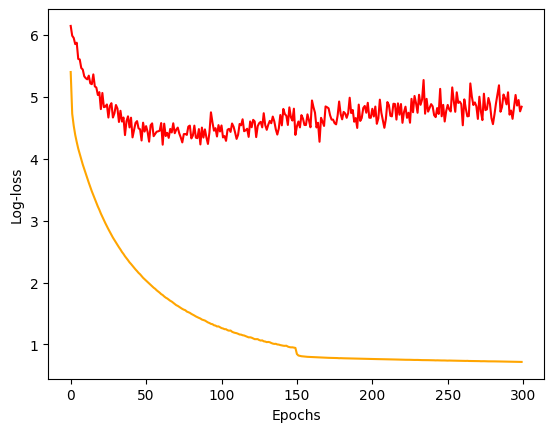

In [112]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

In [113]:
loss_epochs_train[299]

0.718375563621521

In [114]:
loss_epochs_test[299]

4.842200756072998

In [115]:
loss_epochs_test.min()

4.228817462921143

This is the best loss on the test set of all our models. Indeed, both our example sentences are translated quite reasonably. Even the first sentence, "I don't know anything about anything," which was a struggle for our previous models, is almost correctly translated; the only mistake is that it should be "nic o ničem" instead of "nic o nic" (Czech is an inflected language, and *ničem* is the locative case for *nic*). The second translation again shows a slight shift from "I wish I could've gone with you" to "I wish I could've been with you".

In [116]:
pred_token_seq, prob_pred = predict_beam_2(encoder_decoder_cuda, X_test[0][None,:].to(cuda_device), bos_token.to(cuda_device), num_steps = 5, beam_size = 10)
Tatoeba_dataset.vocab_lang_2.to_tokens(pred_token_seq[0])

['nic', 'o', 'nic', 'nevím', '.']

In [117]:
pred_token_seq, prob_pred = predict_beam_2(encoder_decoder_cuda, X_test[3][None,:].to(cuda_device), bos_token.to(cuda_device), num_steps = 10, beam_size = 10)
Tatoeba_dataset.vocab_lang_2.to_tokens(pred_token_seq[0])[:7]

['kéž', 'bych', 'mohl', 'být', 's', 'tebou', '.']

The BLEU score is also significantly improved.

In [118]:
bleu_score = []

for X, Y, Y_len in Tatoeba_dataset.test_dataloader:
    
    for i in range(len(X)):
        
        pred_token_seq, _ = predict_beam_2(encoder_decoder_cuda, X[i][None,:].to(cuda_device), bos_token.to(cuda_device), num_steps = 10, beam_size = 5)
        pred_token_seq = Tatoeba_dataset.vocab_lang_2.to_tokens(pred_token_seq[0])
        
        try:
            idx = pred_token_seq.index('<eos>')
        except:
            idx = len(pred_token_seq)
            
        pred_token_seq = pred_token_seq[:idx]
        if len(pred_token_seq) > 0:
            bleu_score.append(BLEU(pred_token_seq, Tatoeba_dataset.vocab_lang_2.to_tokens(Y[i][1:Y_len[i]]), 3))
        else:
            bleu_score.append(0)

In [119]:
sum(bleu_score)/len(bleu_score)

0.27334346469677245

We could have played with the model architecture a bit more. Nothing is stopping us from using different RNNS for the encoder and the decoder (the encoder could even be bidirectional). We can then use linear layers to transform the hidden states so that they can be passed as hidden states to the decoder, or just pass them as context vectors directly through the inputs. 

However, a notable limitation appears to be the dataset's size.  Let us consider the English-French dataset (which is almost ten times larger), instead of the English-Czech dataset. 

In [120]:
torch.manual_seed(123)

# data loader
Tatoeba_dataset = Tatoeba('D:/nine circles 2/fra.txt', num_train = 220000, batch_size = 250, max_length = 15) 
Tatoeba_train_loader = Tatoeba_dataset.train_dataloader
Tatoeba_test_loader = Tatoeba_dataset.test_dataloader

hidden_size = 256
num_layers = 2
vocab_size_1 = Tatoeba_dataset.vocab_lang_1.__len__()
vocab_size_2 = Tatoeba_dataset.vocab_lang_2.__len__()
embed_size = 256

encoder_decoder_cuda = Encoder_Decoder_2(hidden_size = hidden_size, num_layers = num_layers, vocab_size = [vocab_size_1, vocab_size_2], embed_size = 100, dropout = 0.2).to(cuda_device)

optim_SGD_cuda =  torch.optim.SGD(encoder_decoder_cuda.parameters(), lr = 0.1, momentum = 0.9, weight_decay = 0.0001)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[150], gamma = 0.1)
cross_entropy_loss = nn.CrossEntropyLoss(reduction='none')
max_norm = 10

n_epochs = 200

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t]   = train_test_loop_cuda(Tatoeba_train_loader, Tatoeba_test_loader, encoder_decoder_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda, max_norm) 
end = time.time()
print(end - start)

19864.495735168457


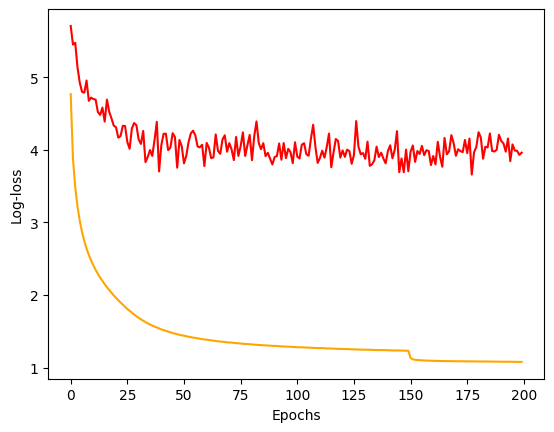

In [121]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

In [122]:
loss_epochs_train[199]

1.0795402526855469

In [123]:
loss_epochs_test[199]

3.9612810611724854

In [124]:
loss_epochs_test.min()

3.659935712814331

On this large dataset, the BLEU score is almost doubled.

In [125]:
bleu_score = []

for X, Y, Y_len in Tatoeba_dataset.test_dataloader:
    
    for i in range(len(X)):
        
        pred_token_seq, _ = predict_beam_2(encoder_decoder_cuda, X[i][None,:].to(cuda_device), bos_token.to(cuda_device), num_steps = 10, beam_size = 5)
        pred_token_seq = Tatoeba_dataset.vocab_lang_2.to_tokens(pred_token_seq[0])
        
        try:
            idx = pred_token_seq.index('<eos>')
        except:
            idx = len(pred_token_seq)
            
        pred_token_seq = pred_token_seq[:idx]
        if len(pred_token_seq) > 0:
            bleu_score.append(BLEU(pred_token_seq, Tatoeba_dataset.vocab_lang_2.to_tokens(Y[i][1:Y_len[i]]), 3))
        else:
            bleu_score.append(0)

In [126]:
sum(bleu_score)/len(bleu_score)

0.48513277884064454

## References <a class="anchor" id="references"></a>

<a id="1">[1]</a> CHO, Kyunghyun, et al. Learning phrase representations using RNN encoder–decoder for statistical machine translation. In: *Proceedings of the 2014 conference on empirical methods in natural language processing (EMNLP).* 2014. p. 1724-1734.

<a id="2">[2]</a> SUTSKEVER, Ilya; VINYALS, Oriol; LE, Quoc V. Sequence to sequence learning with neural networks. *Advances in neural information processing systems*, 2014, 27.

<a id="3">[3]</a> ZHANG, Aston, et al. *Dive into deep learning*. Cambridge University Press, 2023.
